# (31) Grad Bias Var + Dist Consistency (+quintic added)

**Project: `_PoissonGradEstim`**

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:1, dtype: torch.float32  ———  host: mach

In [3]:
import importlib


def purge_modules_from_path(root_dir: str) -> None:
    root_dir = os.path.abspath(root_dir) + os.sep
    for name, mod in list(sys.modules.items()):
        f = getattr(mod, "__file__", None)
        if f is None:
            continue
        try:
            if os.path.abspath(f).startswith(root_dir):
                del sys.modules[name]
        except Exception:
            # Defensive: some modules have weird __file__ values
            pass

# --- 1) Import from _PoissonGradEstim ---
pge_path = pjoin(os.environ['HOME'], 'Dropbox/git', project_name)
sys.path.insert(0, pge_path)
try:
    from analysis.grad_analysis import *
    from analysis.dist_analysis import *
    from analysis.plotting_functions import *
finally:
    sys.path[:] = [p for p in sys.path if p != pge_path]

# Important: purge anything imported from that repo (including a "base" package, if present)
purge_modules_from_path(pge_path)
importlib.invalidate_caches()

# --- 2) Import from PoissonVAE ---
pvae_path = pjoin(os.environ["HOME"], "Dropbox/git", "PoissonVAE")
sys.path.insert(0, pvae_path)

from base.utils_model import load_model


## Make fig dir

In [4]:
fig_dir = fig_base_dir / f'{project_name}_figs-(2026_01_28)'
fig_dir.mkdir(exist_ok=True)

os.listdir(str(fig_dir))

['dist_consistency_wasser.pdf',
 'soft_indicators.pdf',
 'phi.pdf',
 'dist_wasser_lam-[2,20,100].pdf',
 'grad_analysis_all_rates.pdf',
 'dist_consistency_bias.pdf',
 'dist_moments_lam-[2,20,100].pdf',
 'dist_moments_theory.pdf',
 'grad_analysis_lam-20.pdf',
 'dist_consistency_ratio.pdf',
 'grad_analysis_raw_lam-20.pdf']

## Load model

In [5]:
model = 'poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>'
fit = 'indic-sigmoid_mc_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)'

tr, meta = load_model(model, fit, device=device)
print(meta)

{
    'timestamp': '2026_01_06,16:24',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>/indic-sigmoid_m
c_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)',
    'file': 'PoissonVAE+TrainerVAE-3000_(2026_01_06,21:47).pt'
}

## Gradient analysis

### Load $\Phi$

In [6]:
phi = tr.model.fc_dec.get_weight().data
phi = phi.to(device=device, dtype=dtype)
phi.shape

torch.Size([256, 512])

### Load stimulus $x$

In [7]:
batch_size = 90

x = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)
var = tonp(torch.var(x, dim=1))
x = x[np.argsort(var)]

x = x[-batch_size:]

x = x.to(device=device, dtype=dtype)

x.shape

torch.Size([90, 256])

In [8]:
%%time


df = run_gradient_analysis(x, phi, n_samples=100)

Starting Sweep (n_samples=100, batch_size=90)

firing rates:
[0.1, 0.5, 1, 2, 5, 8, 10, 15, 20, 30, 40, 70, 100]

temperatures:
[0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

CPU times: user 1min 33s, sys: 14.4 s, total: 1min 47s
Wall time: 1min 48s


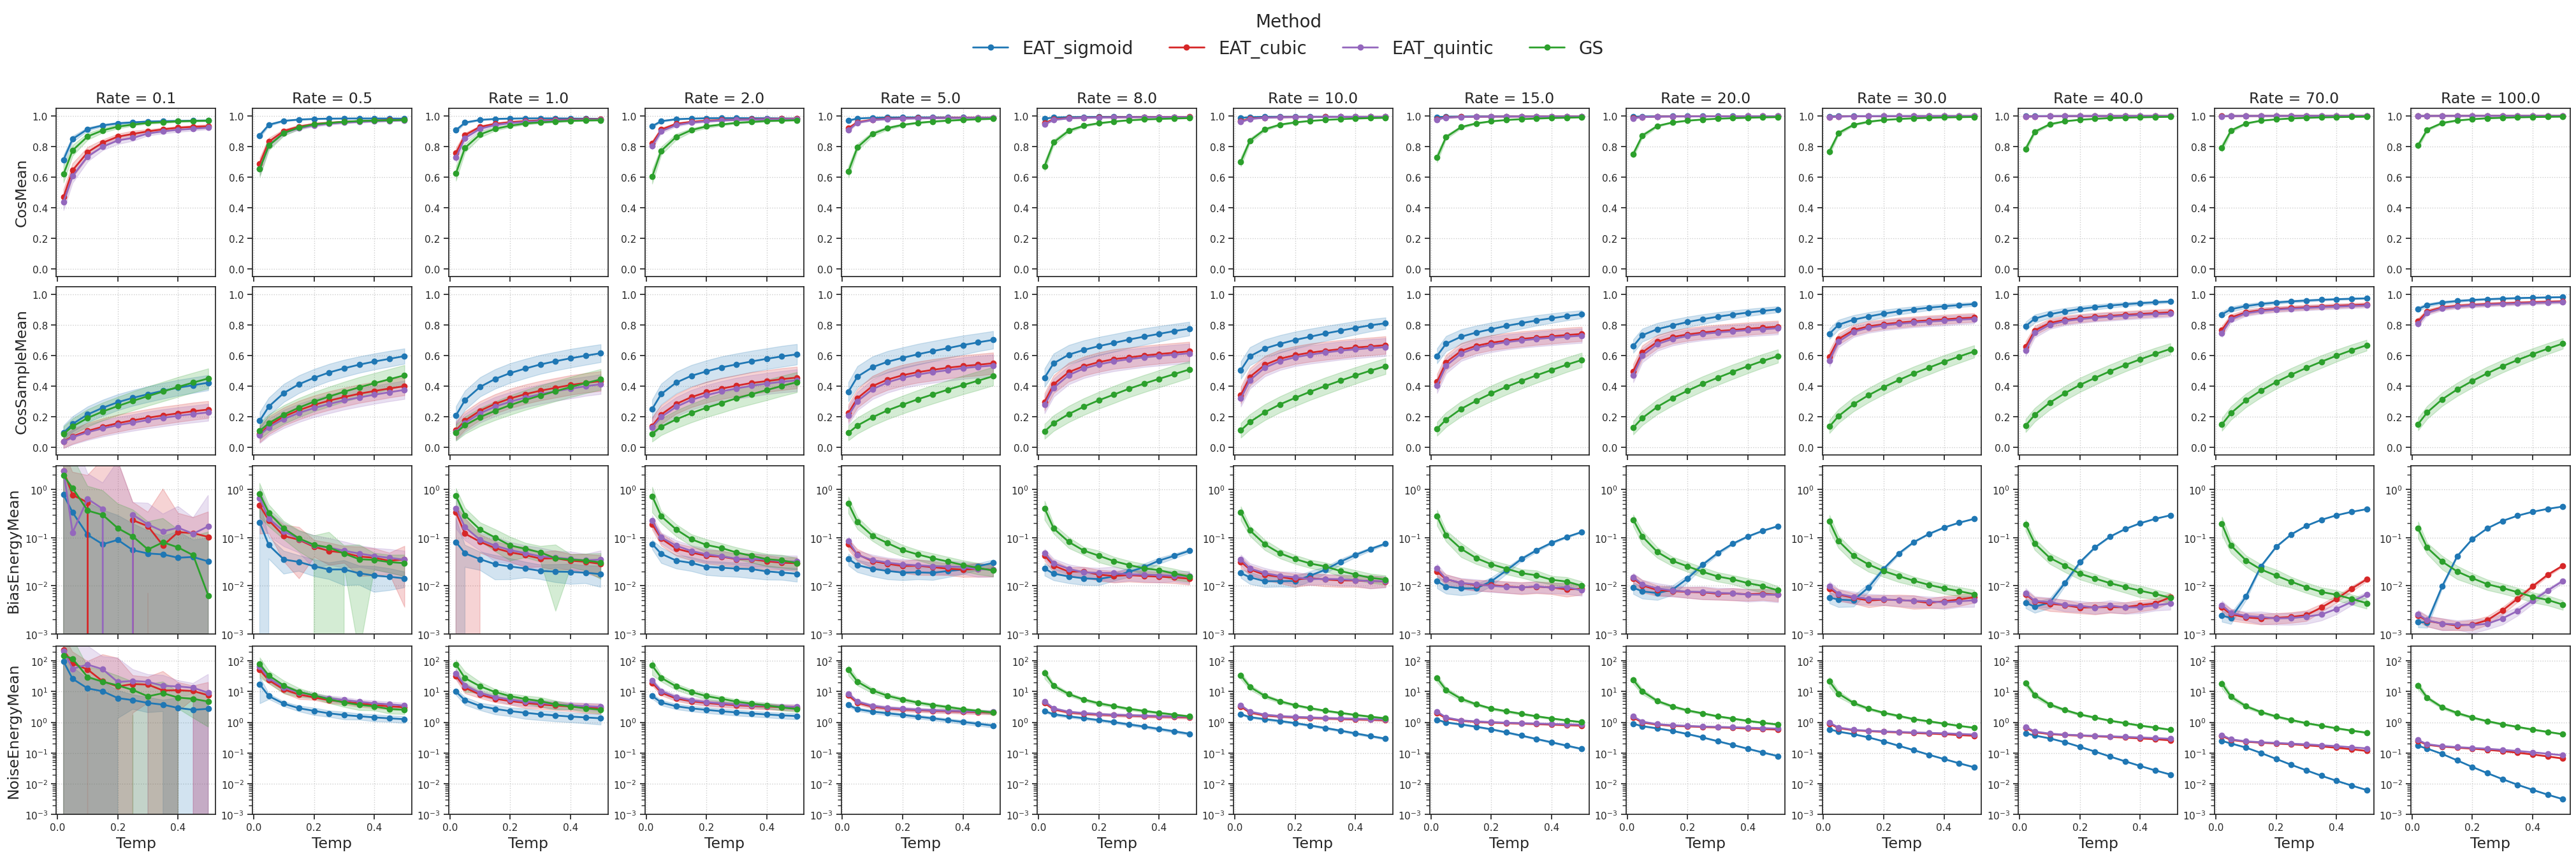

In [9]:
order = ['EAT_sigmoid', 'EAT_cubic', 'EAT_quintic', 'GS']
metrics = ['Cos', 'CosSample', 'BiasEnergy', 'NoiseEnergy']
ylim = {
    'Cos': (-0.05, 1.05),
    'CosSample': (-0.05, 1.05),
    'BiasEnergy': (0.001, 3.1),
    'NoiseEnergy': (0.001, 300.3),
}
yscale = {
    'Cos': 'linear',
    'CosSample': 'linear',
    'BiasEnergy': 'log',
    'NoiseEnergy': 'log',
}

fig, _ = plot_metrics_vs_temp(
    df,
    metrics=metrics,
    order=order,
    ylim=ylim,
    yscale=yscale,
    add_labels=True,
    metrics_as_rows=True,
)
# fig.savefig(fig_dir / 'grad_analysis_all_rates.pdf', bbox_inches='tight')

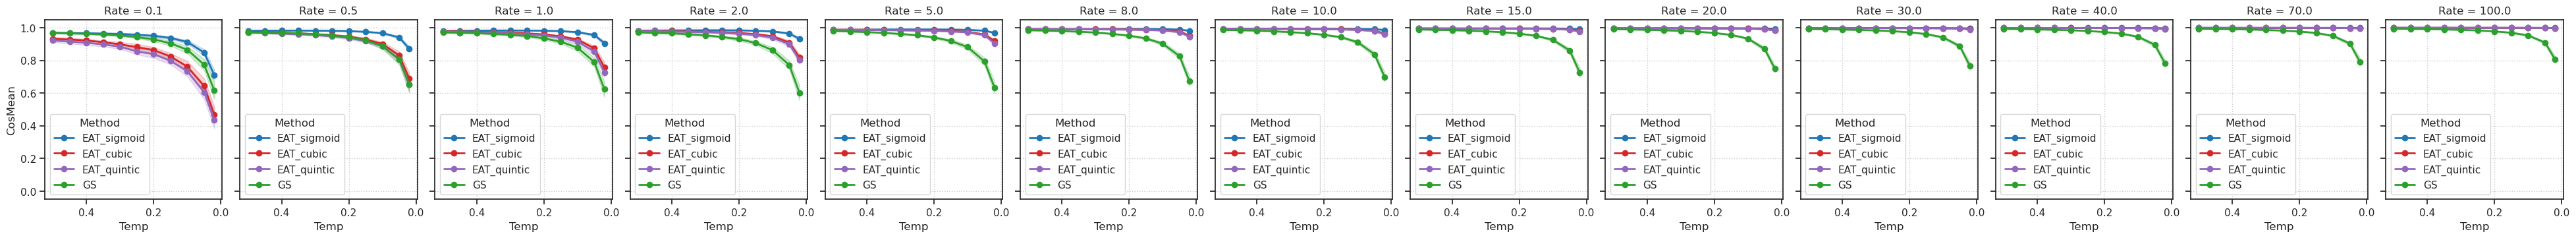

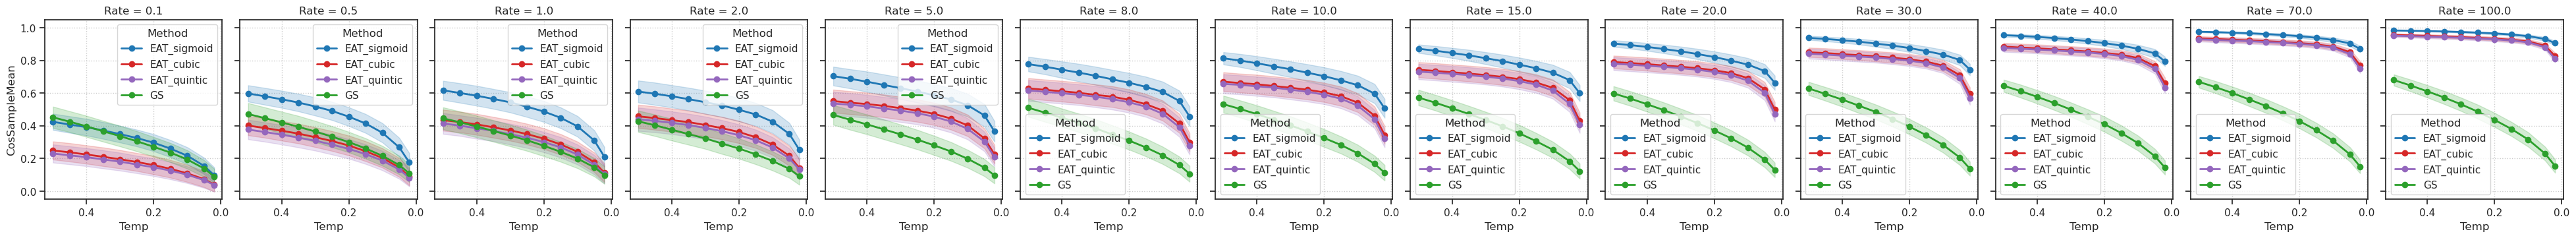

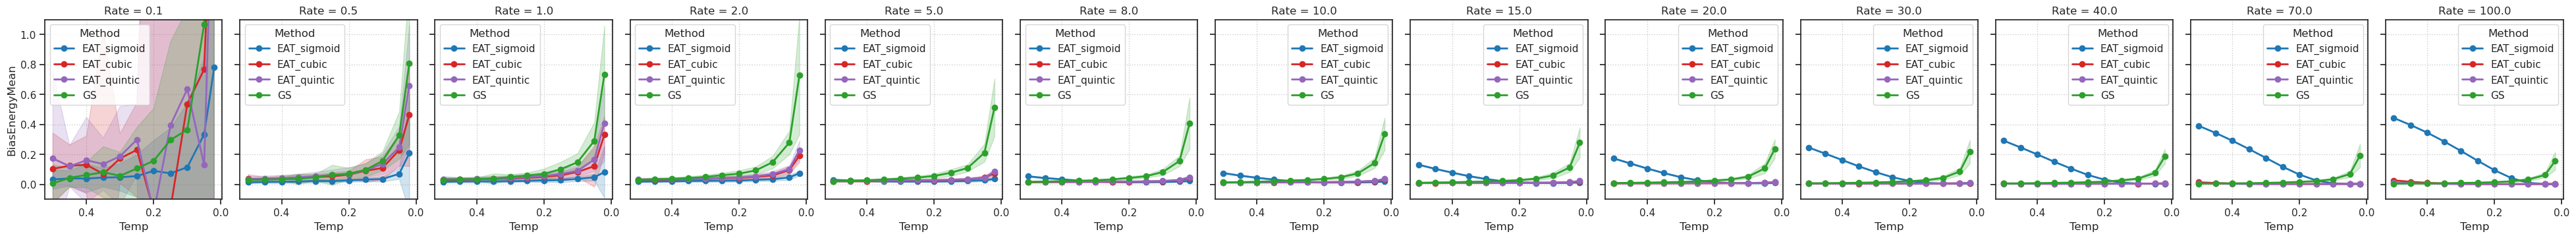

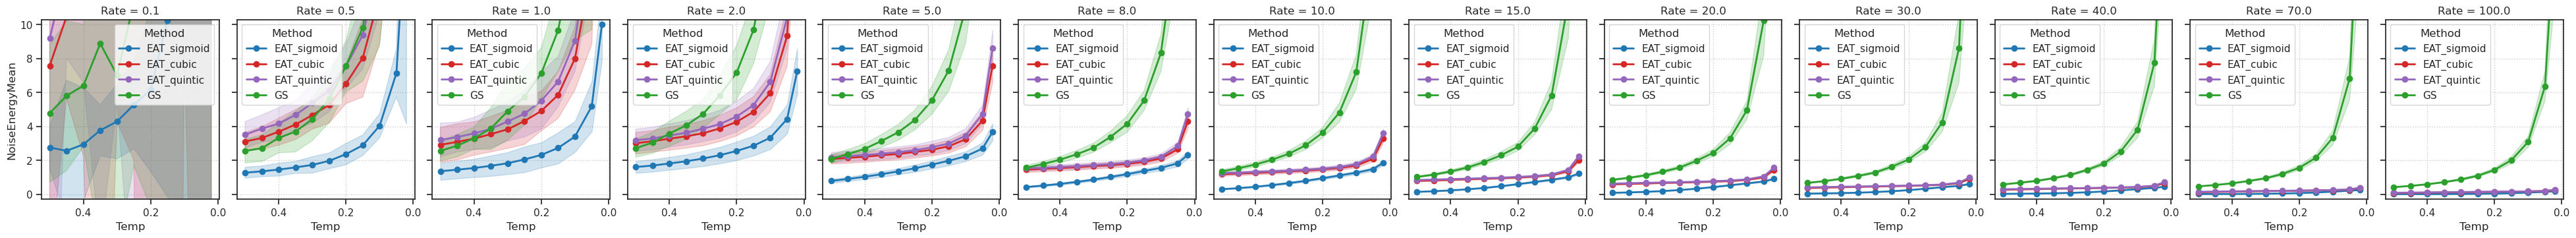

In [10]:
order = ['EAT_sigmoid', 'EAT_cubic', 'EAT_quintic', 'GS']

# cos
_ = plot_metric_vs_temp(df, metric='Cos', order=order, ylim=(-0.05, 1.05))
_ = plot_metric_vs_temp(df, metric='CosSample', order=order, ylim=(-0.05, 1.05))

# energy
_ = plot_metric_vs_temp(df, metric='BiasEnergy', order=order, ylim=(-0.1, 1.1))
_ = plot_metric_vs_temp(df, metric='NoiseEnergy', order=order, ylim=(-0.3, 10.3))

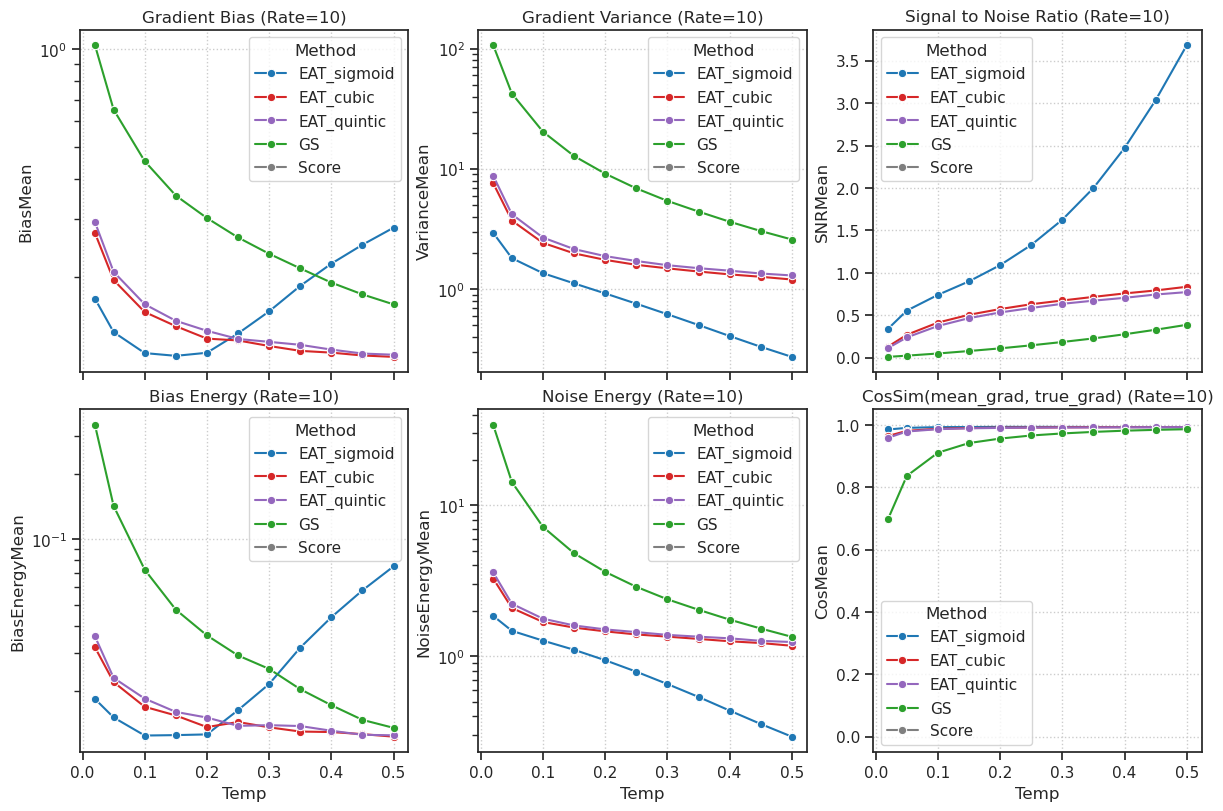

In [11]:
#fig = plot_mean_results(df, lam=0.1)
_ = plot_mean_results(df, lam=10)

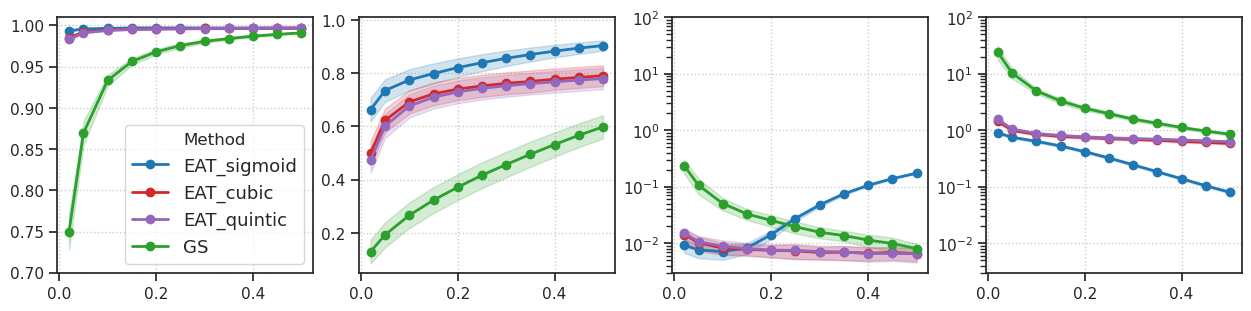

In [12]:
lam = 20
rates_to_plot = [lam]
# temps_to_plot = [0.05, 0.2, 0.5]

df_selected = df.loc[
    df['Rate'].isin(rates_to_plot) # &
    # (df['Temp'] >= 0.05)
]

order = ['EAT_sigmoid', 'EAT_cubic', 'EAT_quintic', 'GS']
metrics = ['Cos', 'CosSample', 'BiasEnergy', 'NoiseEnergy']
ylim = {
    'Cos': (0.70, 1.01),
    'CosSample': (0.05, 1.01),
    'BiasEnergy': (3e-3, 1e2),
    'NoiseEnergy': (3e-3, 1e2),
}
yscale = {
    'Cos': 'linear',
    'CosSample': 'linear',
    'BiasEnergy': 'log',
    'NoiseEnergy': 'log',
}

fig, axes = plot_metrics_vs_temp(
    df_selected,
    metrics=metrics,
    order=order,
    ylim=ylim,
    yscale=yscale,
    sharey=False,
    legend=(0, 0),
    metrics_as_rows=False,
    add_labels=False,
)
# fig.savefig(fig_dir / f'grad_analysis_lam-{lam}.pdf', bbox_inches='tight')

## Consistency analysis

In [13]:
dtype = torch.float32

kws = dict(
    n_samples=50_000,
    n_trials=100,
    device=device,
    dtype=dtype,
)

### Mean and Var (bias/ratios)

In [14]:
%%time


df2 = run_moment_consistency_test(**kws)

Running Moment Consistency Test (n_samples=50000, n_trials=100)

firing rates:
[0.1, 0.5, 1, 2, 5, 8, 10, 15, 20, 30, 40, 70, 100]

temperatures:
[0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

Rates:   0%|          | 0/13 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

...

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

CPU times: user 1min 29s, sys: 11.4 s, total: 1min 40s
Wall time: 1min 41s


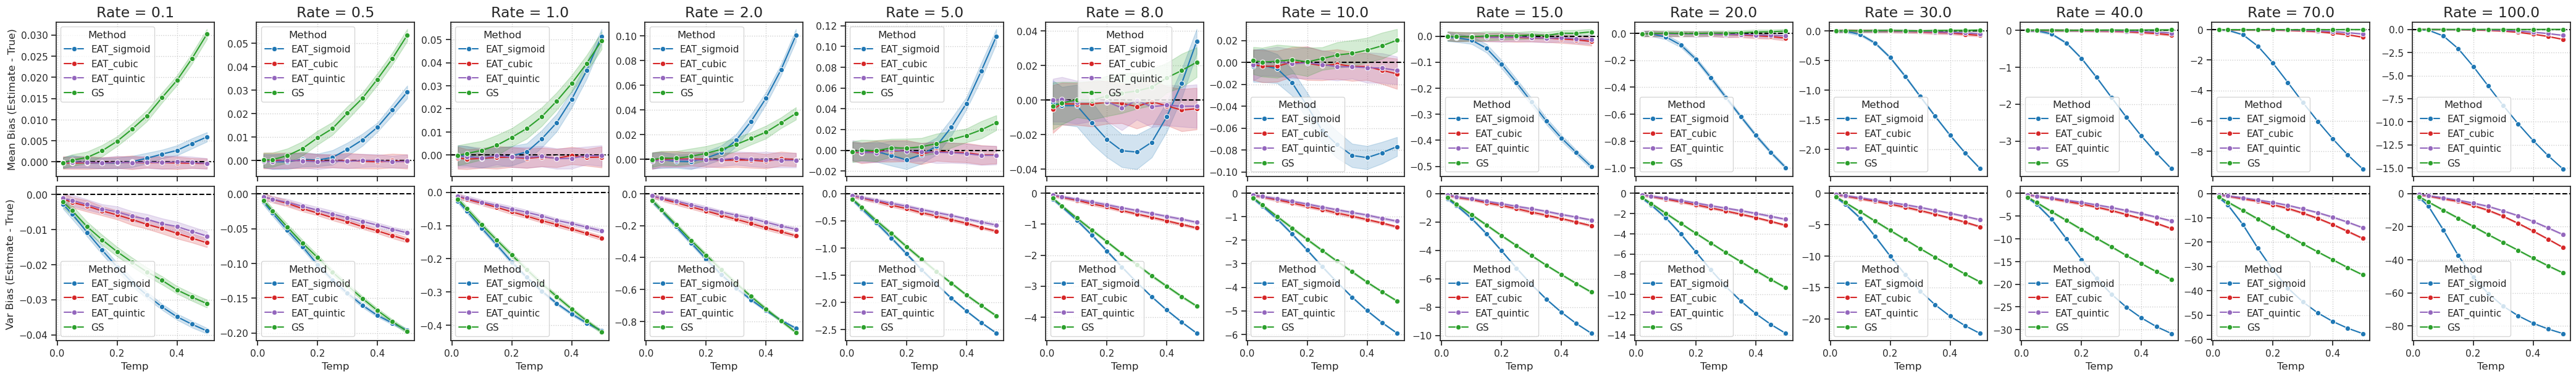

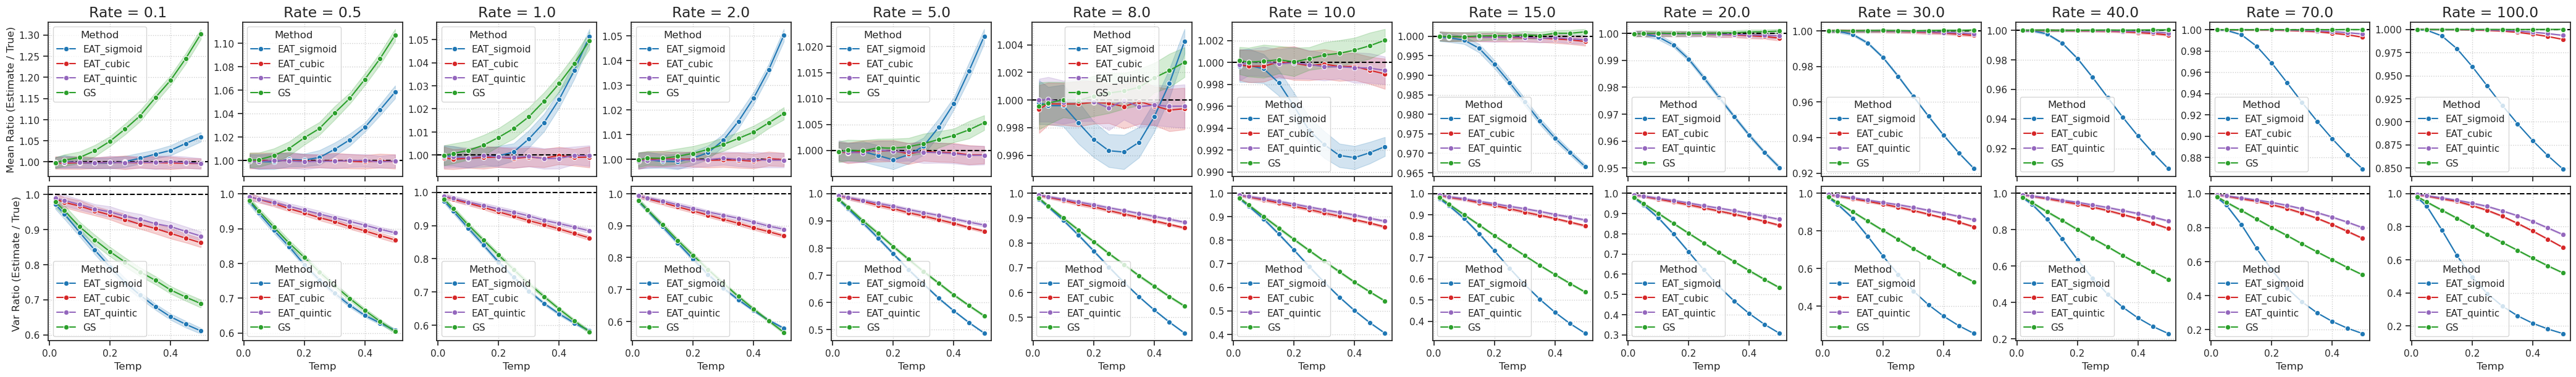

In [15]:
fig, _ = plot_dist_consistency(df2, kind='bias', sharey=False)
# fig.savefig(fig_dir / 'dist_consistency_bias.pdf', bbox_inches='tight')

fig, _ = plot_dist_consistency(df2, kind='ratio', sharey=False)
# fig.savefig(fig_dir / 'dist_consistency_ratio.pdf', bbox_inches='tight')

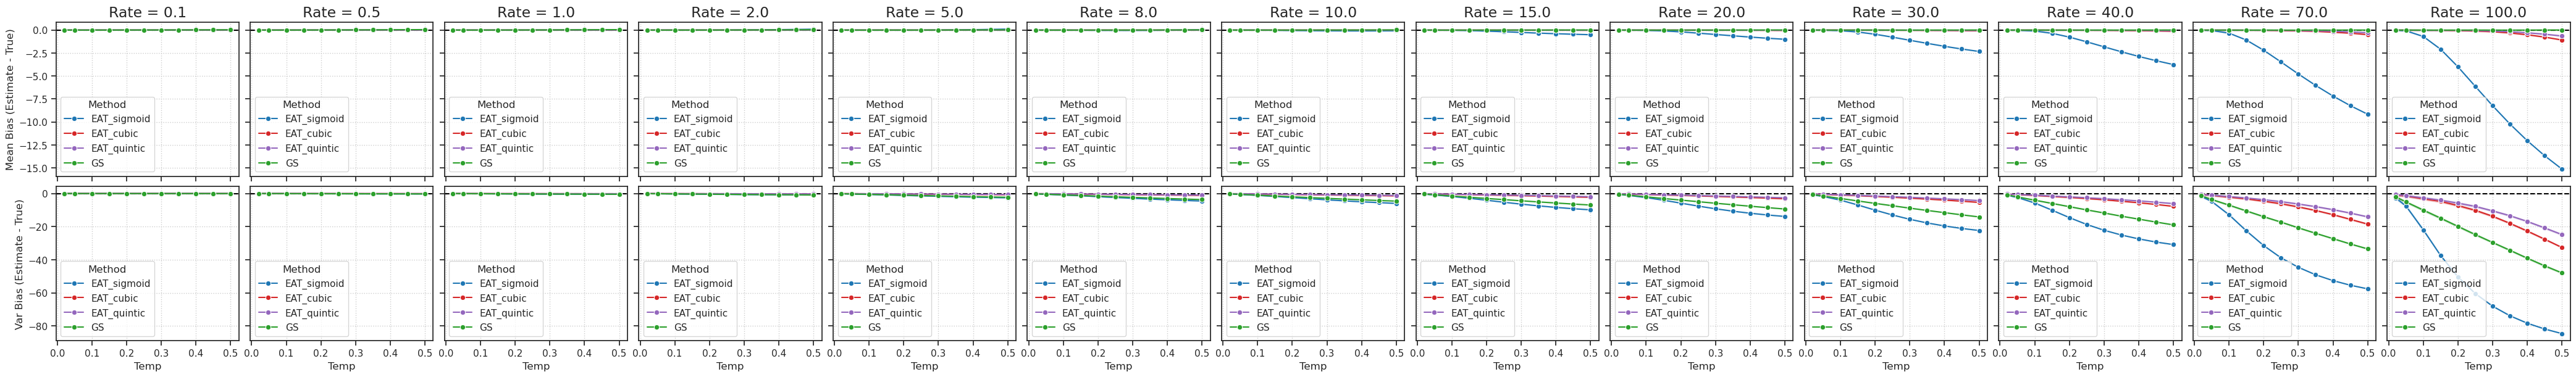

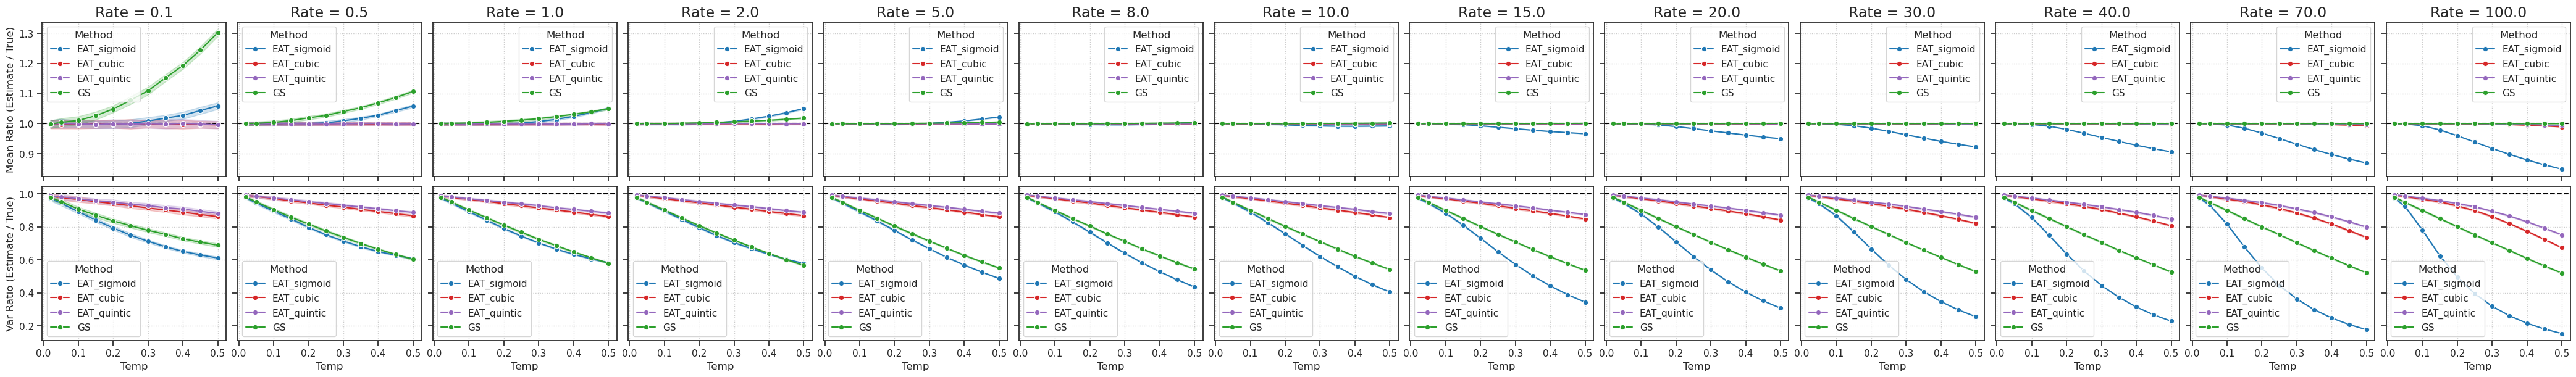

In [16]:
_ = plot_dist_consistency(df2, kind='bias', sharey=True)
_ = plot_dist_consistency(df2, kind='ratio', sharey=True)

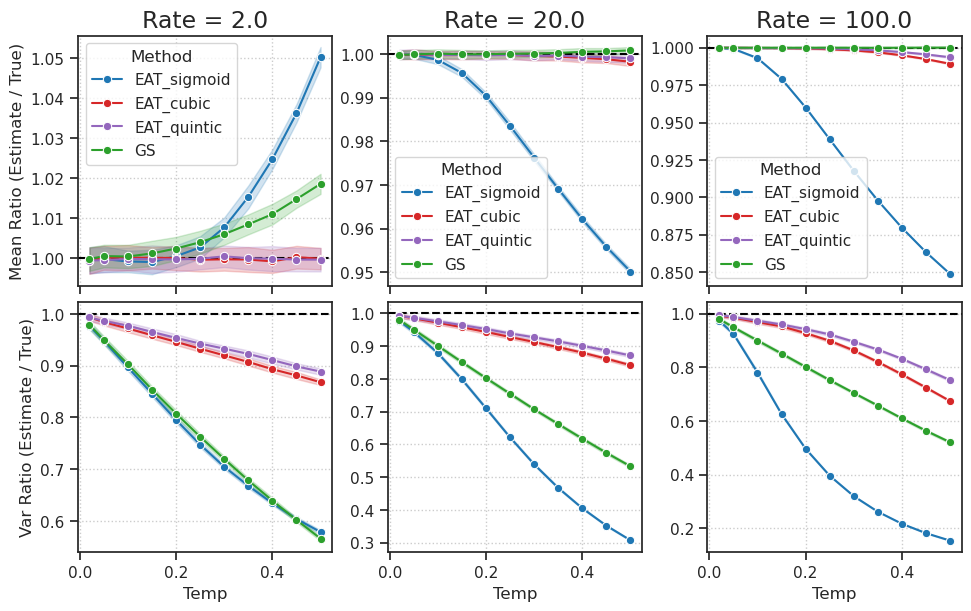

In [17]:
rates_to_plot = [2, 20, 100]

fig, _ = plot_dist_consistency(
    df2.loc[df2['Rate'].isin(rates_to_plot)],
    kind='ratio',
    legend=[(0, 0), (0, 1), (0, 2)],
    add_labels=True,
    sharey=False,
)

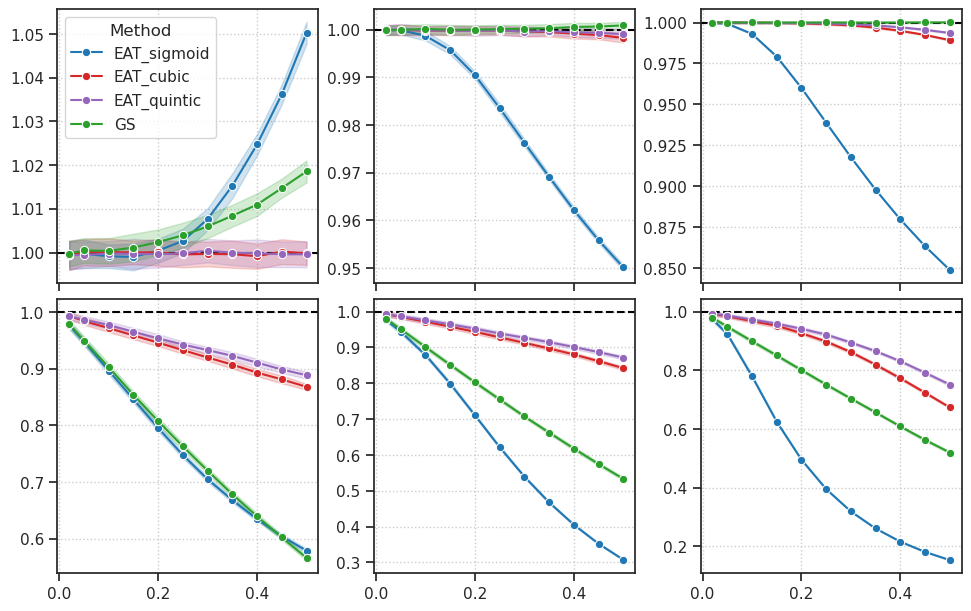

In [18]:
rates_to_plot = [2, 20, 100]

fig, _ = plot_dist_consistency(
    df2.loc[df2['Rate'].isin(rates_to_plot)],
    kind='ratio',
    legend=[(0, 0)],  # True,  # [(0, 0), (0, 1), (0, 2)],
    add_labels=False,
    sharey=False,
)

lam_str = str(rates_to_plot).replace(' ', '')
# fig.savefig(fig_dir / f'dist_moments_lam-{lam_str}.pdf', bbox_inches='tight')

### Wasserstein distance

In [19]:
%%time


df3 = run_wasserstein_analysis(normalization='std', **kws)

Running Wasserstein Analysis (n_samples=50000, n_trials=100, norm=std)

firing rates:
[0.1, 0.5, 1, 2, 5, 8, 10, 15, 20, 30, 40, 70, 100]

temperatures:
[0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

Rates:   0%|          | 0/13 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

...

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

Temps:   0%|          | 0/11 [00:00<?, ?it/s]

CPU times: user 1min 27s, sys: 15.9 s, total: 1min 43s
Wall time: 1min 44s


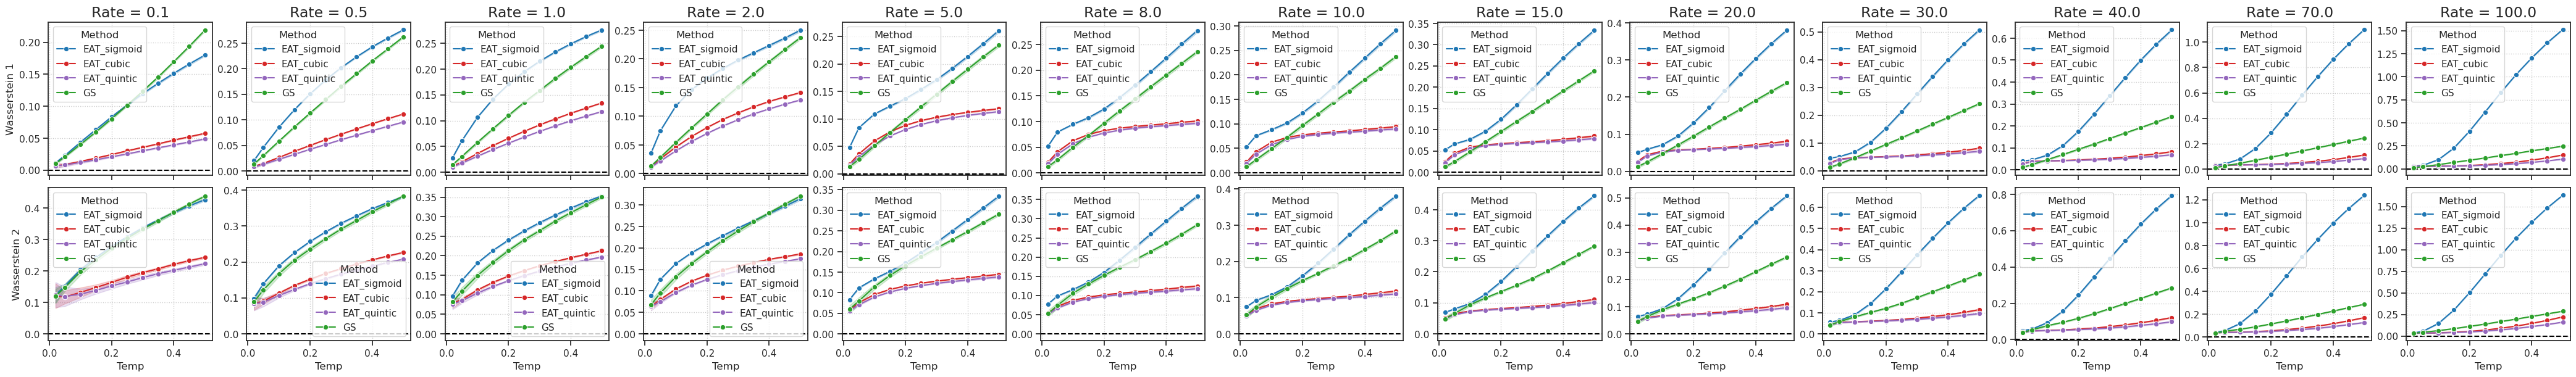

In [20]:
fig, _ = plot_dist_consistency(df3, kind='wasser', sharey=False)
# fig.savefig(fig_dir / 'dist_consistency_wasser.pdf', bbox_inches='tight')

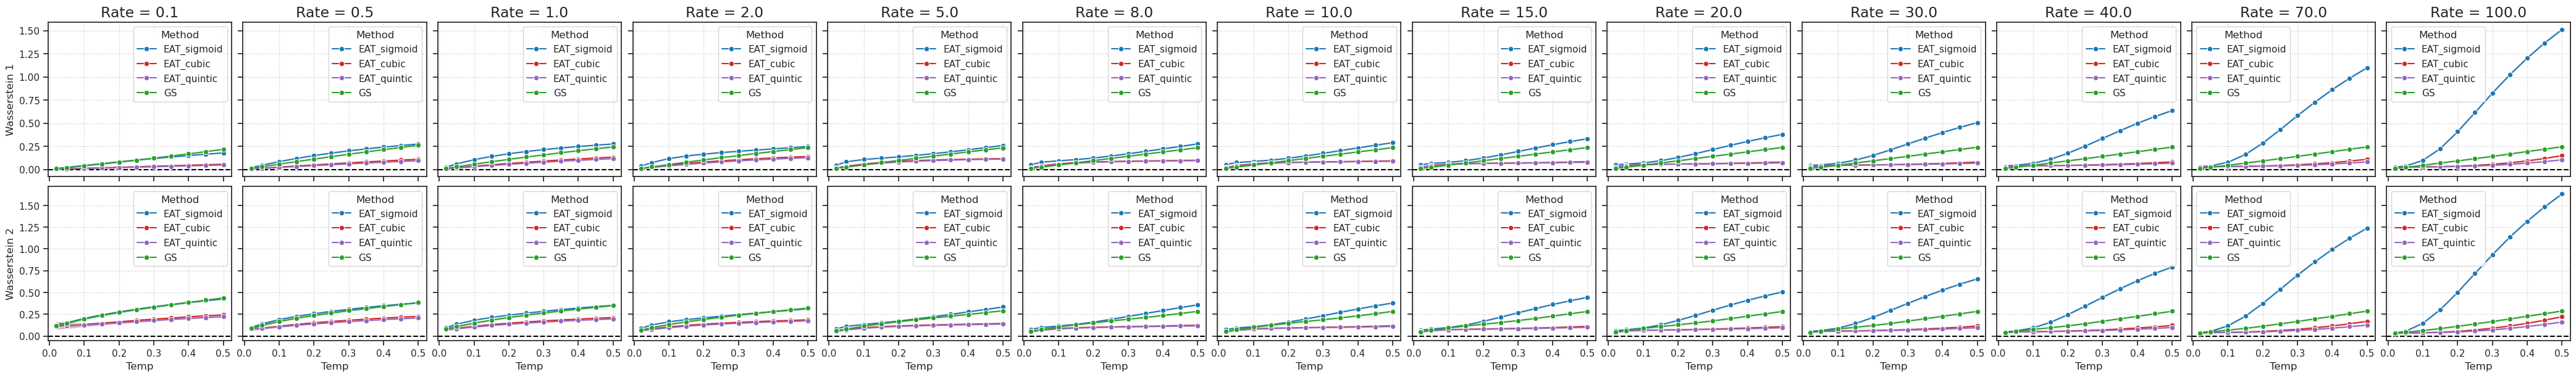

In [21]:
_ = plot_dist_consistency(df3, kind='wasser', sharey=True)

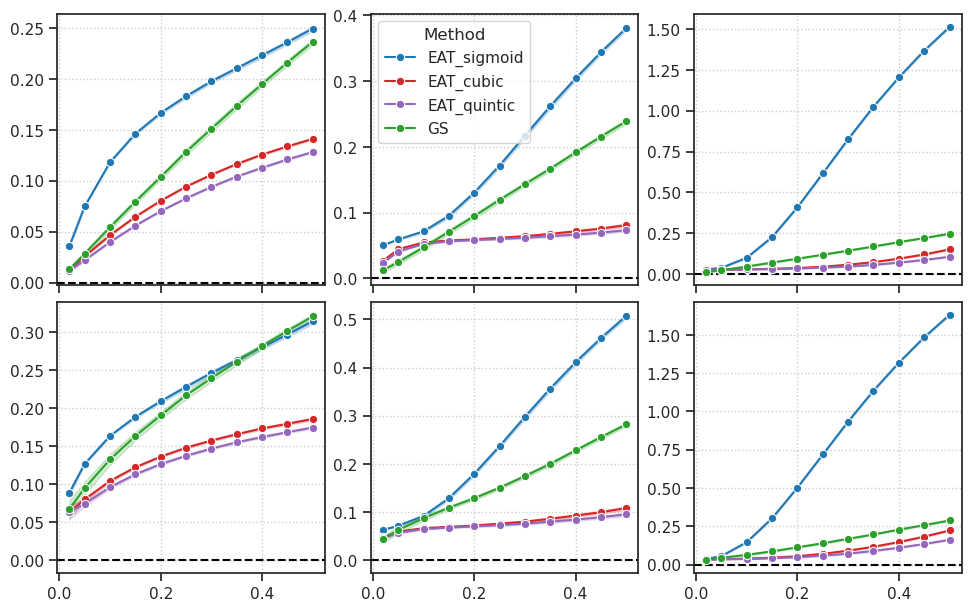

In [22]:
rates_to_plot = [2, 20, 100]
ylims = [-0.005, None, None]

fig, axes = plot_dist_consistency(
    df3.loc[df3['Rate'].isin(rates_to_plot)],
    add_labels=False,
    kind='wasser',
    legend=(0, 1),
    sharey=False,
)
for ax in axes[1, :]:
    ax.remove()

# 1. Set ylim lower bound from list
for ax, ymin_val in zip(axes[0, :], ylims):
    _, ymax = ax.get_ylim()
    ax.set_ylim(ymin_val, ymax)

# 2. Recover x-axis tick labels (lost when row 1 was removed due to sharex)
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Temp')

lam_str = str(rates_to_plot).replace(' ', '')
# fig.savefig(fig_dir / f'dist_wasser_lam-{lam_str}.pdf', bbox_inches='tight')

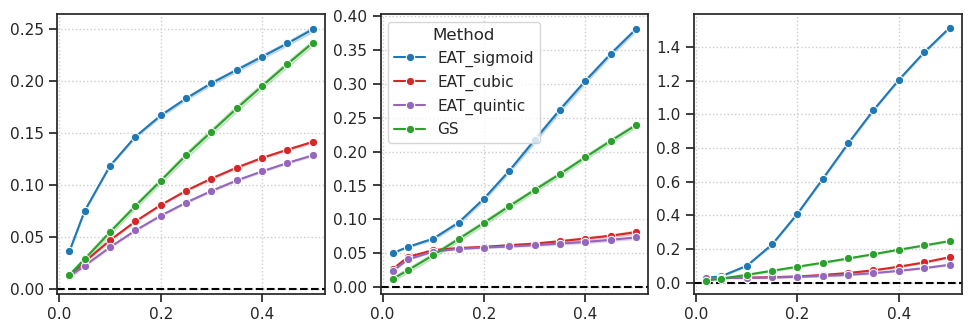

In [23]:
fig